In [1]:
import chess
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from config import *

In [2]:
df = pd.read_parquet("../data/recommendation_dataset.parquet")
df.head()

,fen,next_move,played_by_elo,win_pov,games_count,engine_move,delta,fragility_score,variance,group_count_800,...,is_engine_top2_2100,is_engine_top3_2100,score_2200,recommended_move_2200,is_best_2200,is_top2_2200,is_top3_2200,is_engine_best_2200,is_engine_top2_2200,is_engine_top3_2200
0,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,d7d5,1491,True,145903,g8f6,0.284366,-0.788823,-0.174046,1914.0,...,<NA>,<NA>,0.514066,d7d5,True,True,True,<NA>,<NA>,<NA>
1,rnbqkbnr/ppp1pppp/8/3p4/3P4/8/PPP1PPPP/RNBQKBN...,c1f4,1433,False,145903,c2c4,-0.612085,-0.807181,-0.156649,1830.0,...,<NA>,<NA>,0.529022,c1f4,True,True,True,<NA>,<NA>,<NA>
2,rnbqkbnr/ppp1pppp/8/3p4/3P1B2/8/PPP1PPPP/RN1QK...,g8f6,1491,True,33340,e7e6,0.284366,-0.066764,-0.165798,271.0,...,False,False,0.040923,c8g4,False,False,False,False,False,False
3,rnbqkb1r/ppp1pppp/5n2/3p4/3P1B2/8/PPP1PPPP/RN1...,e2e3,1433,False,30626,e2e3,0.206414,0.116810,-0.163842,228.0,...,False,False,-0.079133,f2f3,False,False,False,False,False,False
4,rnbqkb1r/ppp1pppp/5n2/3p4/3P1B2/4P3/PPP2PPP/RN...,c8g4,1491,True,1497,e7e6,-0.027443,2.405371,-0.102601,11.0,...,False,False,-1.577630,f6h5,False,False,False,False,False,False


## Accuracy: Framework vs. Engine

In [3]:
results = []
grouped = df.groupby("fen").first().reset_index()

for elo in ELOS:
    is_best_col = f"is_best_{elo}"
    is_engine_col = f"is_engine_best_{elo}"

    results.append({
        "elo": elo,
        "avg_is_best": grouped[is_best_col].mean(),
        "avg_is_engine_best": grouped[is_engine_col].mean()
    })

results = pd.DataFrame(results).set_index("elo")
results

,avg_is_best,avg_is_engine_best
elo,,
800,0.208333,0.100000
900,0.465517,0.380000
1000,0.476190,0.444444
1100,0.589041,0.479339
1200,0.596859,0.516340
1300,0.605505,0.537143
1400,0.607843,0.523077
1500,0.642308,0.575000
1600,0.633858,0.577540


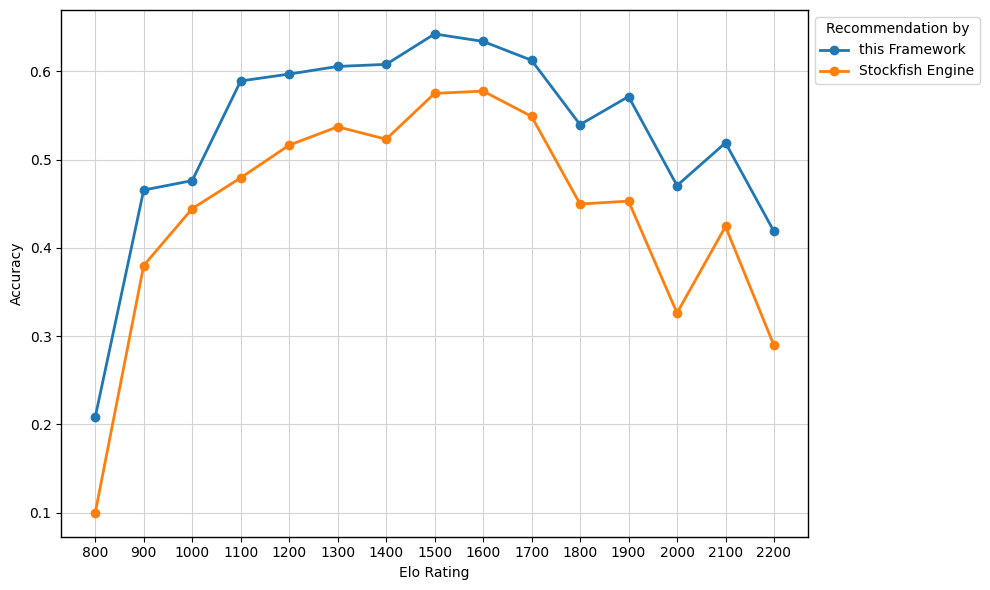

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

for col in results.columns:
    if col == "avg_is_best":
        label = "this Framework"
    else:
        label = "Stockfish Engine"
    ax.plot(results.index, results[col].values, marker='o', linewidth=2, label=label)

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Accuracy")
ax.set_xticks(results.index)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Recommendation by",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/prediction_accuracy.pdf")
plt.show()

## Accuracy with Top2 and Top3

In [5]:
results = []
grouped = df.groupby("fen").first().reset_index()

for elo in ELOS:
    is_best_col = f"is_best_{elo}"
    is_top2_col = f"is_top2_{elo}"
    is_top3_col = f"is_top3_{elo}"
    is_engine1_col = f"is_engine_best_{elo}"
    is_engine2_col = f"is_engine_top2_{elo}"
    is_engine3_col = f"is_engine_top3_{elo}"

    results.append({
        "elo": elo,
        "avg_is_best": grouped[is_best_col].mean(),
        "avg_is_top2": grouped[is_top2_col].mean(),
        "avg_is_top3": grouped[is_top3_col].mean(),
        "avg_is_engine_best": grouped[is_engine1_col].mean(),
        "avg_is_engine_top2": grouped[is_engine2_col].mean(),
        "avg_is_engine_top3": grouped[is_engine3_col].mean()
    })

results = pd.DataFrame(results).set_index("elo")
results

,avg_is_best,avg_is_top2,avg_is_top3,avg_is_engine_best,avg_is_engine_top2,avg_is_engine_top3
elo,,,,,,
800,0.208333,0.333333,0.416667,0.100000,0.200000,0.500000
900,0.465517,0.603448,0.672414,0.380000,0.480000,0.600000
1000,0.476190,0.619048,0.742857,0.444444,0.600000,0.733333
1100,0.589041,0.705479,0.821918,0.479339,0.685950,0.785124
1200,0.596859,0.759162,0.848168,0.516340,0.692810,0.830065
1300,0.605505,0.743119,0.830275,0.537143,0.708571,0.845714
1400,0.607843,0.772549,0.870588,0.523077,0.743590,0.882051
1500,0.642308,0.780769,0.869231,0.575000,0.720000,0.875000
1600,0.633858,0.767717,0.885827,0.577540,0.732620,0.866310


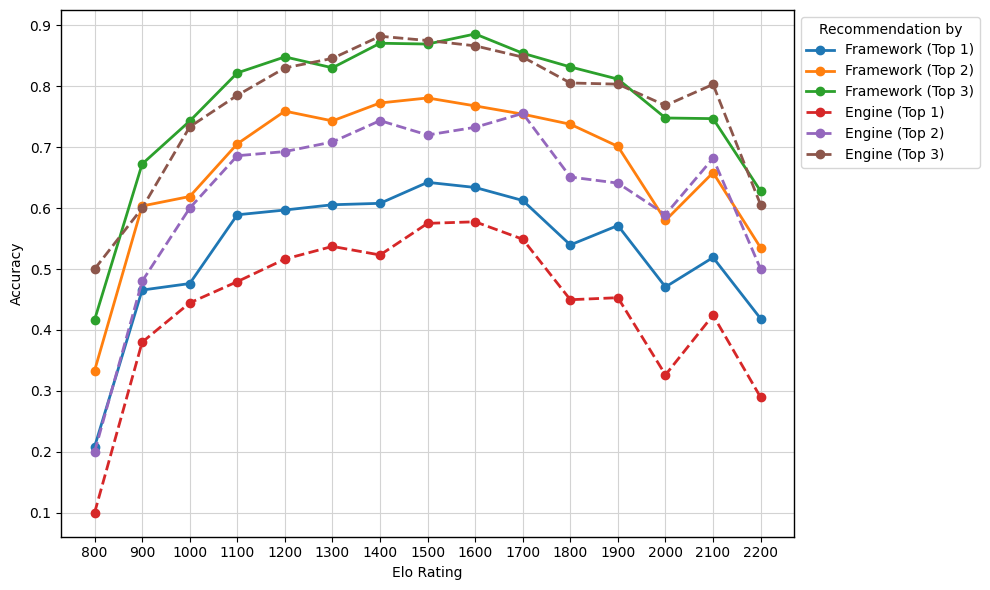

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

plt.plot(results.index, results["avg_is_best"].values, marker="o", linewidth=2, label="Framework (Top 1)")
plt.plot(results.index, results["avg_is_top2"].values, marker="o", linewidth=2, label="Framework (Top 2)")
plt.plot(results.index, results["avg_is_top3"].values, marker="o", linewidth=2, label="Framework (Top 3)")

plt.plot(results.index, results["avg_is_engine_best"].values, marker="o", linestyle="--", linewidth=2,
         label="Engine (Top 1)")
plt.plot(results.index, results["avg_is_engine_top2"].values, marker="o", linestyle="--", linewidth=2,
         label="Engine (Top 2)")
plt.plot(results.index, results["avg_is_engine_top3"].values, marker="o", linestyle="--", linewidth=2,
         label="Engine (Top 3)")

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Accuracy")
ax.set_xticks(results.index)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Recommendation by",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/prediction_accuracy_topk.pdf")
plt.show()

## Feature Importance × Accuracy

In [7]:
importances = pd.read_parquet("../data/importances.parquet")
importances

,elo_800,elo_900,elo_1000,elo_1100,elo_1200,elo_1300,elo_1400,elo_1500,elo_1600,elo_1700,elo_1800,elo_1900,elo_2000,elo_2100,elo_2200
delta,0.128676,0.141242,0.141989,0.171576,0.150897,0.170482,0.139739,0.137887,0.143655,0.151811,0.139444,0.140267,0.148339,0.131127,0.136315
fragility_score,0.608803,0.617594,0.607709,0.563436,0.555458,0.546021,0.584892,0.565787,0.571242,0.585927,0.589108,0.592978,0.607101,0.618243,0.621190
variance,0.262521,0.241164,0.250302,0.264988,0.293644,0.283497,0.275369,0.296327,0.285103,0.262262,0.271449,0.266755,0.244560,0.250629,0.242495


In [8]:
if importances.columns.dtype == object:
    importances.columns = (
        importances.columns
        .astype(str)
        .str.extract(r"(\d+)", expand=False)
        .astype(int)
    )
if results.index.dtype == object:
    results.index = (
        results.index
        .astype(str)
        .str.extract(r"(\d+)", expand=False)
        .astype(int)
    )

fi_df = importances.T.reindex(results.index).fillna(0)
y_acc = results["avg_is_best"].reindex(fi_df.index).fillna(0).values
feature_arrays = []

for feat in FEATURES:
    arr = fi_df[feat].values * y_acc
    feature_arrays.append(arr)

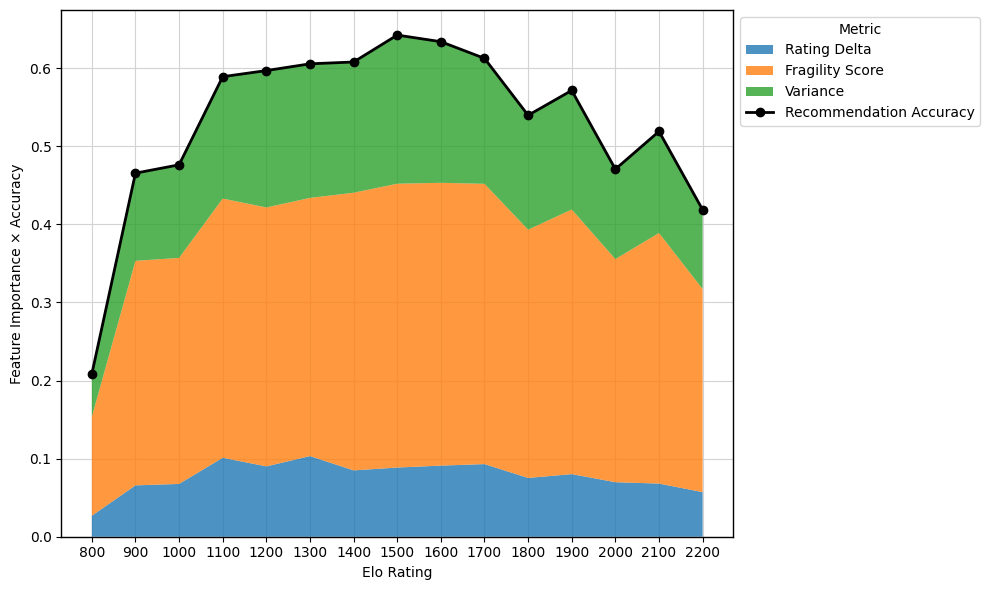

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

ax.stackplot(
    fi_df.index,
    *feature_arrays,
    labels=[FEATURE_LABELS[f] for f in FEATURES],
    alpha=0.8
)
ax.plot(
    fi_df.index,
    y_acc,
    color="black",
    marker="o",
    linewidth=2,
    label="Recommendation Accuracy"
)

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Feature Importance × Accuracy")
ax.set_xticks(fi_df.index)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Metric",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/accuracy_x_importance.pdf")
plt.show()

## Logistic Regression Accuracy

In [10]:
df["f_cross_d"] = df["fragility_score"] * df["delta"]
df["f_cross_v"] = df["fragility_score"] * df["variance"]
df["d_cross_v"] = df["delta"] * df["variance"]
target_columns = [col for col in df.columns if col.startswith("is_best_") or col.startswith("is_engine_best_")]

print("Logistic Regression Accuracy:")
for y_feature in target_columns:
    engine_flag = "Engine" if y_feature.split("_")[1] == "engine" else "Framework"
    elo = y_feature.split("_")[-1]
    df_reg = df[pd.notna(df[y_feature])]

    selected_features = ["fragility_score", "delta", "variance", "f_cross_d", "f_cross_v", "d_cross_v"]
    X = df_reg[selected_features]
    y = df_reg[y_feature].astype(bool)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=1, stratify=y
    )

    log_model = LogisticRegression()
    log_model.fit(X_train, y_train)
    y_pred_log = log_model.predict(X_test)
    acc_log = accuracy_score(y_test, y_pred_log)
    print(f"Elo {elo} ({engine_flag}): {acc_log * 100:.1f} %")

Logistic Regression Accuracy:
Elo 800 (Framework): 86.3 %
Elo 800 (Engine): 99.2 %
Elo 900 (Framework): 84.1 %
Elo 900 (Engine): 92.5 %
Elo 1000 (Framework): 81.2 %
Elo 1000 (Engine): 92.1 %
Elo 1100 (Framework): 75.0 %
Elo 1100 (Engine): 89.5 %
Elo 1200 (Framework): 67.2 %
Elo 1200 (Engine): 83.2 %
Elo 1300 (Framework): 85.0 %
Elo 1300 (Engine): 81.7 %
Elo 1400 (Framework): 74.4 %
Elo 1400 (Engine): 86.5 %
Elo 1500 (Framework): 76.6 %
Elo 1500 (Engine): 84.6 %
Elo 1600 (Framework): 66.9 %
Elo 1600 (Engine): 85.0 %
Elo 1700 (Framework): 80.9 %
Elo 1700 (Engine): 81.2 %
Elo 1800 (Framework): 77.8 %
Elo 1800 (Engine): 93.9 %
Elo 1900 (Framework): 70.4 %
Elo 1900 (Engine): 86.9 %
Elo 2000 (Framework): 81.5 %
Elo 2000 (Engine): 94.4 %
Elo 2100 (Framework): 81.2 %
Elo 2100 (Engine): 83.4 %
Elo 2200 (Framework): 87.0 %
Elo 2200 (Engine): 90.7 %


## Sample position

In [11]:
valid_fens = df.groupby("fen")["next_move"].nunique()
valid_fens = valid_fens[valid_fens == 3].index
random_fen = pd.Series(valid_fens).sample(1).iloc[0]
filtered = df[df["fen"] == random_fen].drop_duplicates(subset=["fen", "next_move"])
filtered.drop(columns="fen").set_index("next_move").T

next_move,b8c6,c5d4,c5c4
played_by_elo,1473,1422,1788
win_pov,False,False,True
games_count,248,208,103
engine_move,g8f6,g8f6,g8f6
delta,0.050509,-0.105396,-1.586489
...,...,...,...
is_engine_top2_2200,<NA>,<NA>,<NA>
is_engine_top3_2200,<NA>,<NA>,<NA>
f_cross_d,0.040516,-0.015825,-0.389185
f_cross_v,-0.023434,0.011073,0.013405


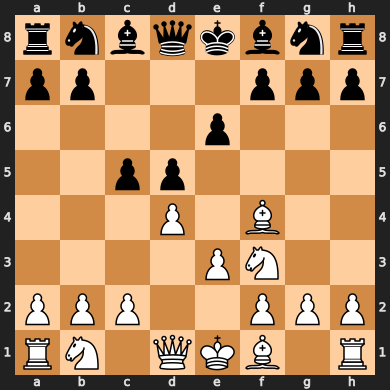

In [12]:
chess.Board(random_fen)

In [13]:
df_sample = filtered.set_index('next_move')
columns_starting_with_winrate = df_sample.columns[df_sample.columns.str.startswith("winrate_")]
filtered_columns_df = df_sample[columns_starting_with_winrate]
filtered_columns_df.columns = filtered_columns_df.columns.str.replace(r"^winrate_", "", regex=True)
winrate_df = filtered_columns_df.T
winrate_df.index = winrate_df.index.astype(int)
top_line = winrate_df.max(axis=1).astype(float).values
bottom_line = (winrate_df.max(axis=1) - 0.01).astype(float).values
elo_index = winrate_df.index.values

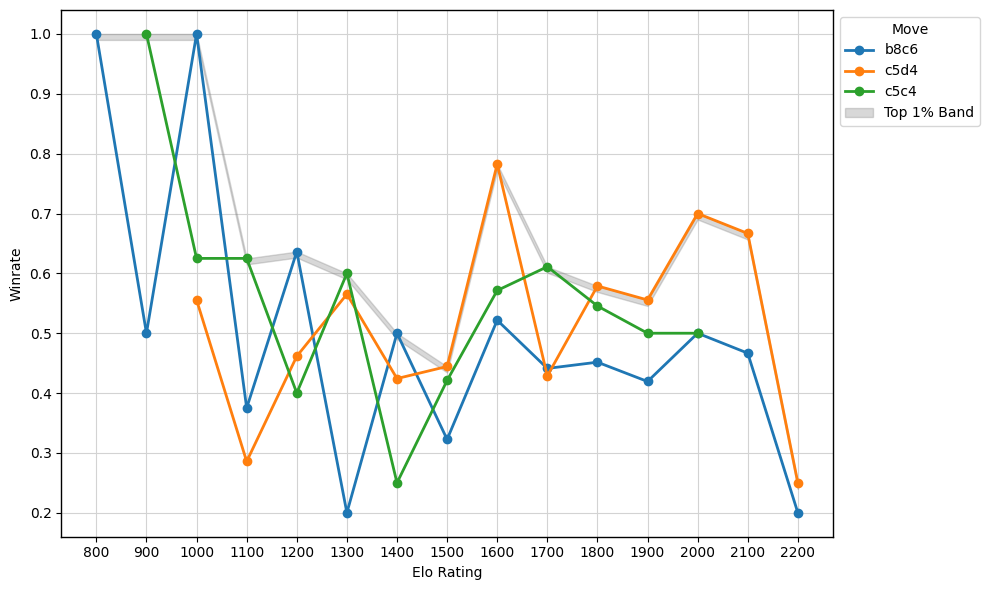

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

for col in winrate_df.columns:
    ax.plot(elo_index, winrate_df[col].values, marker='o', linewidth=2, label=col)

ax.fill_between(elo_index, bottom_line, top_line, color='gray', alpha=0.3, label="Top 1% Band")
ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Winrate")
ax.set_xticks(winrate_df.index)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Move",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/winrate_example.pdf")
plt.show()